# Persian Digits Hand Writing Image Classification **Fully Connected Neural Network**

## 1.Import Libraries

In [12]:
import cv2
import numpy as np
from scipy import io
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.losses import SparseCategoricalCrossentropy
from keras.layers import Dense, Dropout, Softmax, Flatten


## 2. Persian Handwritten Digits Dataset

A dataset containing handwritten Persian digit images (`۰` to `۹`) used to train and evaluate the neural network classification model.


In [2]:
digits = io.loadmat('Data_hoda_full.mat')

## 3. Data Inspection

Inspect the dataset structure by checking its available keys and shapes.


In [3]:
digits.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [4]:
print(f'Data Shape: {digits['Data'].shape}\nLabels Shape: {digits['labels'].shape}')

Data Shape: (60000, 1)
Labels Shape: (60000, 1)


## 4. Data Reshaping

Remove unnecessary singleton dimensions from the data and labels using np.squeeze().

In [5]:
digits['Data'] = np.squeeze(digits['Data'])
digits['labels'] = np.squeeze(digits['labels'])
print(f'Data Shape: {digits['Data'].shape}\nLabels Shape: {digits['labels'].shape}')

Data Shape: (60000,)
Labels Shape: (60000,)


## 5. Visualize Sample Image

Display a sample handwritten digit from the dataset along with its corresponding label.

Enter the number of image sample: 40


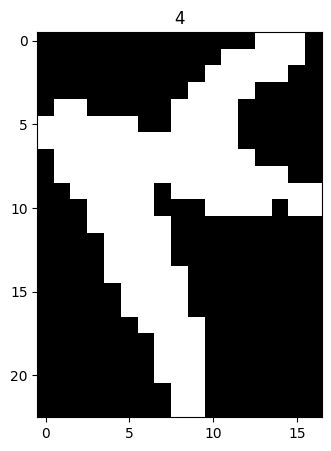

In [6]:
i = int(input('Enter the number of image sample: '))
plt.figure(figsize= (5, 5))
plt.imshow(digits['Data'][i], cmap= 'gray')
plt.title(digits['labels'][i]);

## 6.Image Preprocessing

The original images have different dimensions, so all images are resized to **8 × 8** pixels and normalized to the range `[0, 1]`.

After preprocessing:

```python
(60000, 8, 8)
```

All **60,000 images** now have a consistent shape suitable for model training.


In [7]:
print(f'Sample 1: {digits['Data'][30].shape}\nSample 2: {digits['Data'][100].shape}\nSmaple 3: {digits['Data'][450].shape}')

Sample 1: (18, 17)
Sample 2: (54, 11)
Smaple 3: (20, 32)


In [8]:
digits['Data'] = np.array([cv2.resize(img, (9, 9)) / 255 for img in digits['Data']])
print(f'{digits['Data'].shape}')

(60000, 9, 9)


## 7.Train-Test Split

The dataset is split into **80% training** and **20% testing** data using `train_test_split`.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(digits['Data'], digits['labels'], test_size= 0.2, random_state= 42)
print(f'X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\ny_train shape: {y_train.shape}\ny_test shape: {y_test.shape}')

X_train shape: (48000, 9, 9)
X_test shape: (12000, 9, 9)
y_train shape: (48000,)
y_test shape: (12000,)


## 8.Neural Network Model

A fully connected neural network is created with ReLU activations, Dropout layers to reduce overfitting, and 10 output neurons for the 10 classes.

The model uses Adam optimizer and SparseCategoricalCrossentropy with from_logits=True.

## Experiment 1 — Baseline Model

The initial neural network was trained for **30 epochs** and evaluated on both the training and test sets. This model was used as the **baseline** for comparing the results of subsequent experiments.

In [46]:
model1 = Sequential([
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.35),
    Dense(10)
])

model1.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

## Model1 Training
The model is trained for **30 epochs** with a batch size of **32**.
**20%** of the training data is used for validation.

In [47]:
his1 = model1.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=30,
    verbose=2,
    validation_split=0.2
)

Epoch 1/30
1200/1200 - 7s - 6ms/step - accuracy: 0.9248 - loss: 0.2466 - val_accuracy: 0.9728 - val_loss: 0.0871
Epoch 2/30
1200/1200 - 5s - 4ms/step - accuracy: 0.9712 - loss: 0.0950 - val_accuracy: 0.9790 - val_loss: 0.0653
Epoch 3/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9761 - loss: 0.0758 - val_accuracy: 0.9803 - val_loss: 0.0611
Epoch 4/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9801 - loss: 0.0650 - val_accuracy: 0.9819 - val_loss: 0.0608
Epoch 5/30
1200/1200 - 5s - 4ms/step - accuracy: 0.9823 - loss: 0.0559 - val_accuracy: 0.9809 - val_loss: 0.0619
Epoch 6/30
1200/1200 - 5s - 4ms/step - accuracy: 0.9837 - loss: 0.0524 - val_accuracy: 0.9816 - val_loss: 0.0591
Epoch 7/30
1200/1200 - 5s - 4ms/step - accuracy: 0.9845 - loss: 0.0475 - val_accuracy: 0.9822 - val_loss: 0.0603
Epoch 8/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9860 - loss: 0.0427 - val_accuracy: 0.9812 - val_loss: 0.0618
Epoch 9/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9872 - loss: 0.0399 - val_accuracy: 0.9855 - 

In [48]:
test_loss, test_acc= model1.evaluate(X_test, y_test)
train_loss, train_acc = model1.evaluate(X_train, y_train)
print(f'Experiment 1:\nTest Accuracy: {test_acc * 100:.2f}\nTest Loss: {test_loss:.2f}\nTrain Accuracy: {train_acc * 100:.2f}\nTrain Loss: {train_loss:.2f}')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9816 - loss: 0.0874
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9951 - loss: 0.0192
Experiment 1:
Test Accuracy: 98.16
Test Loss: 0.09
Train Accuracy: 99.51
Train Loss: 0.02


## Visualizing Experiment 1: Accuracy and Loss

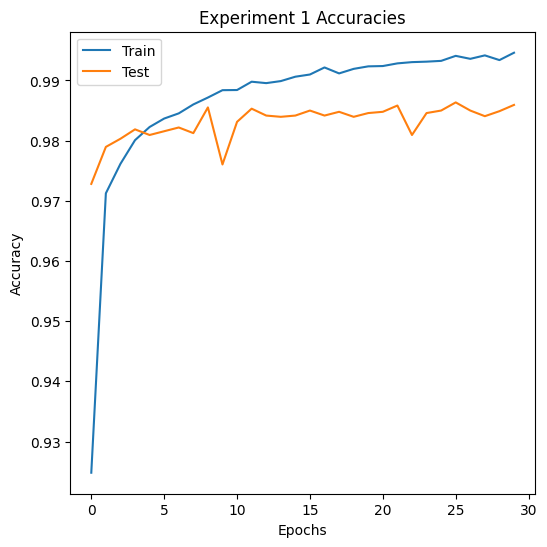

In [62]:
plt.figure(figsize= (6, 6))
plt.plot(his1.history['accuracy'], label= 'Train')
plt.plot(his1.history['val_accuracy'], label= 'Test')
plt.title('Experiment 1 Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("experiment1_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

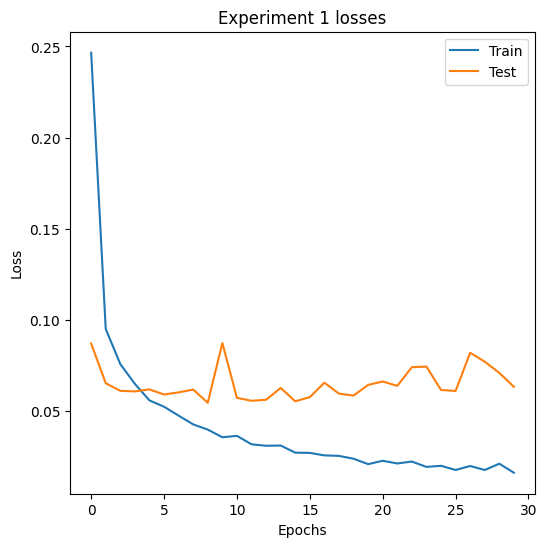

In [64]:
plt.figure(figsize= (6, 6))
plt.plot(his1.history['loss'], label= 'Train')
plt.plot(his1.history['val_loss'], label= 'Test')
plt.title('Experiment 1 losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("experiment1_loss.png", dpi=300, bbox_inches="tight")
plt.show()


## Experiment 2 — Model Architecture Improvement
The model architecture was simplified and balanced by using fewer layers with 128 → 128 → 64 neurons and adjusted Dropout rates.

In [51]:
model2 = Sequential([
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.15),
    Dense(128, activation='relu'),
    Dropout(0.20),
    Dense(64, activation='relu'),
    Dropout(0.15),
    Dense(10)
])

model2.compile(
    loss=SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

## Model2 Training


The model is trained for **30 epochs** with a batch size of **32**.
**20%** of the training data is used for validation.


In [52]:
his2 = model2.fit(X_train, y_train,
                batch_size= 32,
                epochs= 30,
                verbose= 2,
                validation_split= 0.2)

Epoch 1/30
1200/1200 - 7s - 6ms/step - accuracy: 0.9105 - loss: 0.2940 - val_accuracy: 0.9722 - val_loss: 0.0819
Epoch 2/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9668 - loss: 0.1110 - val_accuracy: 0.9793 - val_loss: 0.0643
Epoch 3/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9738 - loss: 0.0885 - val_accuracy: 0.9826 - val_loss: 0.0534
Epoch 4/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9773 - loss: 0.0760 - val_accuracy: 0.9849 - val_loss: 0.0507
Epoch 5/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9793 - loss: 0.0676 - val_accuracy: 0.9831 - val_loss: 0.0536
Epoch 6/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9811 - loss: 0.0618 - val_accuracy: 0.9861 - val_loss: 0.0460
Epoch 7/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9824 - loss: 0.0567 - val_accuracy: 0.9839 - val_loss: 0.0529
Epoch 8/30
1200/1200 - 4s - 3ms/step - accuracy: 0.9837 - loss: 0.0525 - val_accuracy: 0.9852 - val_loss: 0.0468
Epoch 9/30
1200/1200 - 4s - 4ms/step - accuracy: 0.9851 - loss: 0.0474 - val_accuracy: 0.9870 - 

In [53]:
test_loss, test_acc= model2.evaluate(X_test, y_test)
train_loss, train_acc = model2.evaluate(X_train, y_train)
print(f'Test Accuracy: {test_acc * 100:.2f}\nTest Loss: {test_loss:.2f}\nTrain Accuracy: {train_acc * 100:.2f}\nTrain Loss: {train_loss:.2f}')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9856 - loss: 0.0576
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9956 - loss: 0.0161
Test Accuracy: 98.56
Test Loss: 0.06
Train Accuracy: 99.56
Train Loss: 0.02


## Visualizing Experiment 2: Accuracy and Loss

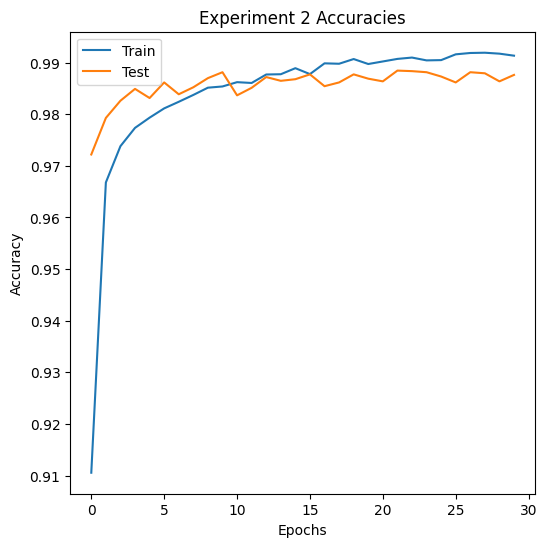

In [65]:
plt.figure(figsize= (6, 6))
plt.plot(his2.history['accuracy'], label= 'Train')
plt.plot(his2.history['val_accuracy'], label= 'Test')
plt.title('Experiment 2 Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("experiment2_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

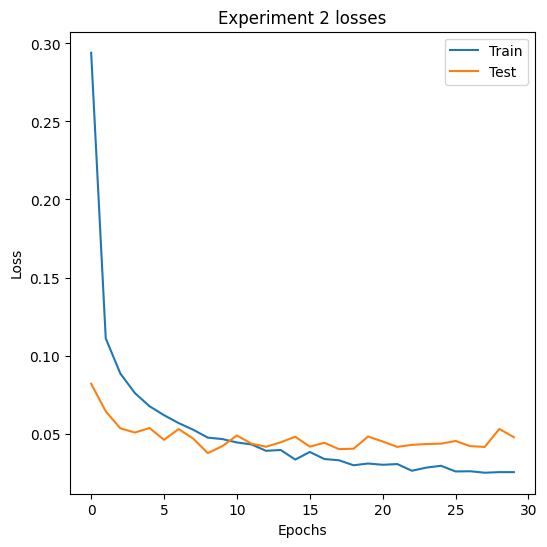

In [66]:
plt.figure(figsize= (6, 6))
plt.plot(his2.history['loss'], label= 'Train')
plt.plot(his2.history['val_loss'], label= 'Test')
plt.title('Experiment 2 losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("experiment2_loss.png", dpi=300, bbox_inches="tight")
plt.show()

##  Test Model with Softmax

In [67]:
test_model = Sequential([
    model2,
    Softmax()
])

Enter the image number for predict: 768


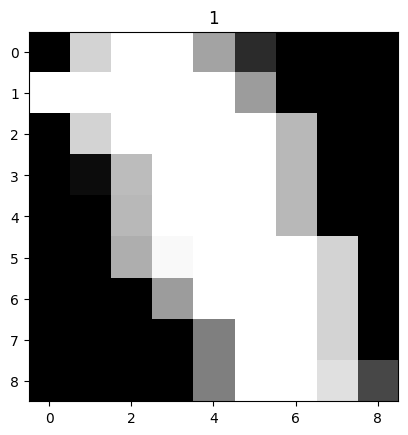

In [85]:
i = int(input('Enter the image number for predict: '))
test_img = np.expand_dims(X_test[i], axis= 0)
y_predict = np.array(test_model(test_img)).argmax()
plt.title(y_predict)
plt.imshow(X_test[i], cmap= 'gray');


In [ ]:
\